# Détection du cancer du sein à partir de données cliniques


Ce notebook présente une démarche complète et chronologique pour la construction d’un modèle de prédiction du cancer du sein, incluant la provenance des données, le choix des paramètres, la préparation des données, la modélisation, l’évaluation et l’interprétabilité.

In [1]:
# Importation des librairies nécessaires pour le traitement des données et la modélisation
import os
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split ,GridSearchCV
from sklearn.preprocessing import StandardScaler ,LabelEncoder,OneHotEncoder
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier


# Provenance des données


Le fichier `Breast_Cancer.csv` contient des données cliniques anonymisées sur des patientes atteintes de cancer du sein. Les variables incluent l'âge, le stade tumoral (TNM), le grade, la taille de la tumeur, le statut hormonal, la survie et le statut vital. Ce format est conforme aux standards internationaux (SEER, WHO, UCI).

In [2]:
# Chargement des données et affichage des premières lignes
TRAIN_PATH = 'Breast_Cancer.csv'

TARGET = 'Status'

train = pd.read_csv(TRAIN_PATH)

print(train.shape)

train.head()

(4024, 16)


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [3]:
# Informations sur les colonnes et types de données
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [4]:
# Statistiques descriptives des variables
train.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [5]:
# Sélection des colonnes à utiliser pour l'entraînement
FEATURES_COLS =train.columns
USED_COLS = [c for c in FEATURES_COLS if c not in TARGET]

# Methologies 

- **Modèles utilisés :** RandomForestClassifier et XGBClassifier, reconnus pour leur robustesse sur les données médicales tabulaires.
- **Séparation des données :** 70% pour l'entraînement/validation, 30% pour le test, puis 15% du train pour la validation.
- **Encodage :** LabelEncoder pour transformer les variables catégorielles en numériques.
- **Imputation :** SimpleImputer (médiane) pour gérer les valeurs manquantes.
- **Normalisation :** StandardScaler pour homogénéiser les échelles.
- **Optimisation :** GridSearchCV pour ajuster les hyperparamètres du Random Forest (n_estimators, max_samples, max_features).
- **Class_weight :** Utilisation de 'balanced_subsample' pour compenser un éventuel déséquilibre des classes.
- **Évaluation :** F1-score, adapté aux problèmes de classification médicale ou il est plus grave de rater un malade qu'attribuer une maladie a tort.
- **Sauvegarde :** joblib pour exporter le modèle et les colonnes pour une utilisation future (ex : interface Streamlit).


Ces choix garantissent la reproductibilité, la robustesse et l’interprétabilité du modèle pour une application médicale.

# Encodage des variables catégorielles en valeurs numériques


In [6]:
le = LabelEncoder()
for col in FEATURES_COLS:
    train[col] = le.fit_transform(train[col])

In [7]:
# Vérification du résultat de l'encodage
train.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,38,2,1,0,0,0,1,3,1,3,1,1,23,0,59,0
1,20,2,1,1,1,2,0,2,1,34,1,1,13,4,61,0
2,28,2,0,2,2,4,0,2,1,62,1,1,13,6,74,0
3,28,2,1,0,0,0,1,3,1,17,1,1,1,0,83,0
4,17,2,1,1,0,1,1,3,1,40,1,1,2,0,49,0


# Vérification de l’équilibre des classes dans la variable cible

# Affichage de la distribution des classes

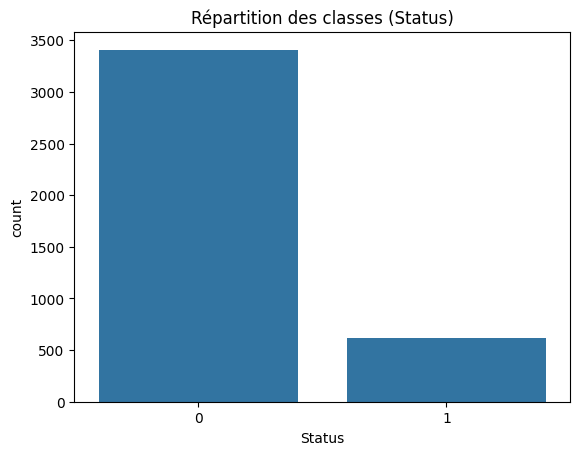

Status
0    0.846918
1    0.153082
Name: proportion, dtype: float64


In [8]:

sns.countplot(x=train[TARGET])
plt.title('Répartition des classes (Status)')
plt.show()

# Affichage des proportions
print(train[TARGET].value_counts(normalize=True))

# Séparation des données en ensembles d'entraînement, de validation et de test


In [9]:
X_train_dev , X_test , y_train_dev , y_test = train_test_split(train[USED_COLS],train[TARGET],test_size=0.3)

X_train , X_dev , y_train , y_dev = train_test_split(X_train_dev,y_train_dev,test_size=0.15)



# Comparaison automatisée des modèles avec validation croisée


In [10]:
models = {
    'RandomForest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier()
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_dev, y_train_dev, cv=5, scoring='f1')
    print(f"{name} F1-score (CV): {scores.mean():.4f} ± {scores.std():.4f}")

RandomForest F1-score (CV): 0.6086 ± 0.0299
XGBoost F1-score (CV): 0.5931 ± 0.0310
LogisticRegression F1-score (CV): 0.5551 ± 0.0394
SVM F1-score (CV): 0.5032 ± 0.0420
KNN F1-score (CV): 0.5452 ± 0.0484


## Randomforest est le meilleur model pour ce cas
Nous allons donc travailler avec lui

In [12]:
# Optimisation des hyperparamètres du RandomForest avec GridSearchCV
params_rf = {
    'n_estimators':[100,200,300,400,500],
    'max_samples':[0.8,0.9],
    'max_features':[0.8,0.9]
}

grid_rf = GridSearchCV(models["RandomForest"], params_rf, cv=5)

print('Grid training Started ...')
grid_rf.fit(X_train_dev, y_train_dev)

Grid training Started ...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_features': [0.8, 0.9], 'max_samples': [0.8, 0.9], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

# Affichage des meilleurs paramètres trouvés pour RandomForest


In [13]:
print(grid_rf.best_params_)

{'max_features': 0.8, 'max_samples': 0.8, 'n_estimators': 500}


# Pipeline complète et sécurisée avec RandomForest

In [14]:
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k='all')) 
])

pipe_rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', grid_rf.best_estimator_)
])

# Entraînement de la pipeline RandomForest sur l'ensemble train_dev et prédiction sur le test

In [15]:
pipe_rf.fit(X_train_dev, y_train_dev)

y_predict_rf = pipe_rf.predict(X_test)

# Calcul du F1-score sur l'ensemble test pour RandomForest


In [16]:
f1score_rf = f1_score(y_test, y_predict_rf)

# Affichage du F1-score final pour RandomForest

In [19]:
print(f1score_rf)

0.6622950819672131


# Sauvegarde du modèle RandomForest et des colonnes pour une utilisation future (ex : interface Streamlit)


In [17]:
import joblib

joblib.dump(pipe_rf, 'cancer_detection_pipeline_rf.pkl')

model_columns = list(X_train_dev.columns)
joblib.dump(model_columns, 'cancer_features_names.pkl')

print("Pipeline RandomForest cancer sauvegardée avec succès !")

Pipeline RandomForest cancer sauvegardée avec succès !


# Analyse d’interprétabilité du modèle


**Feature Importance (Random Forest)**


La feature importance permet d’identifier les variables les plus influentes dans la prédiction du modèle. Elle est calculée automatiquement par le RandomForestClassifier.


**Interprétation locale avec SHAP**


SHAP (SHapley Additive exPlanations) permet d’expliquer l’impact de chaque variable sur la prédiction pour chaque observation. C’est une méthode reconnue pour l’interprétabilité des modèles complexes.


Exemple d’utilisation dans ce notebook :

                   Feature  Importance
14         Survival Months    0.456083
0                      Age    0.112318
9               Tumor Size    0.095690
12  Regional Node Examined    0.093824
13   Reginol Node Positive    0.068911
2           Marital Status    0.033418
5                6th Stage    0.026224
7                    Grade    0.023366
11     Progesterone Status    0.018527
3                 T Stage     0.017461
1                     Race    0.015808
4                  N Stage    0.012917
6            differentiate    0.012312
10         Estrogen Status    0.010663
8                  A Stage    0.002478


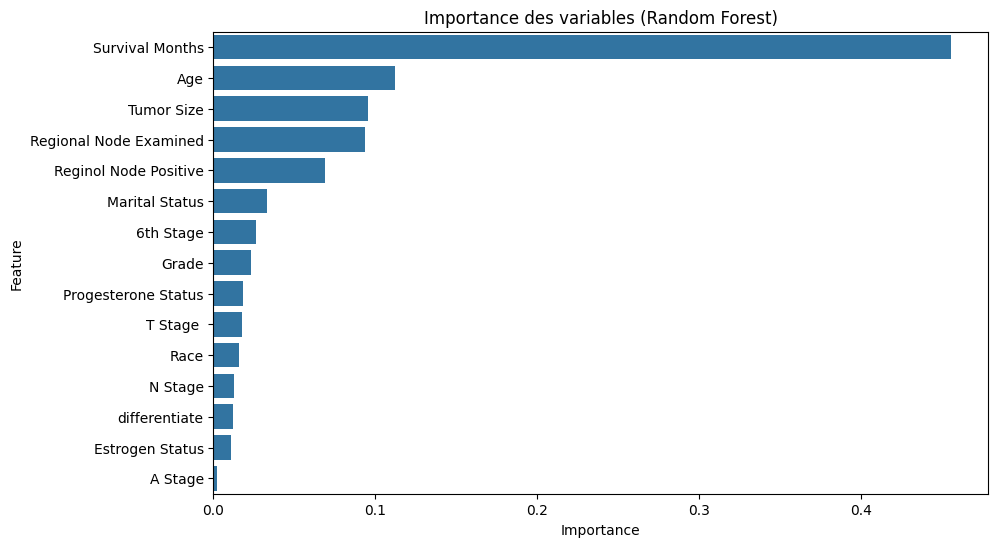

In [18]:
# Affichage de l’importance des variables (Random Forest)
importances = pipe_rf.named_steps['model'].feature_importances_
features = X_train_dev.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

# Visualisation
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Importance des variables (Random Forest)')
plt.show()